
==================== Testing Models on CAD.csv (D1) ====================
Finished Logistic Regression on CAD.csv (D1): AUC = 0.8092
Finished KNN on CAD.csv (D1): AUC = 0.7369
Finished Decision Tree on CAD.csv (D1): AUC = 0.5954
Finished Random Forest on CAD.csv (D1): AUC = 0.7690

Generating Confusion Matrices for CAD.csv...


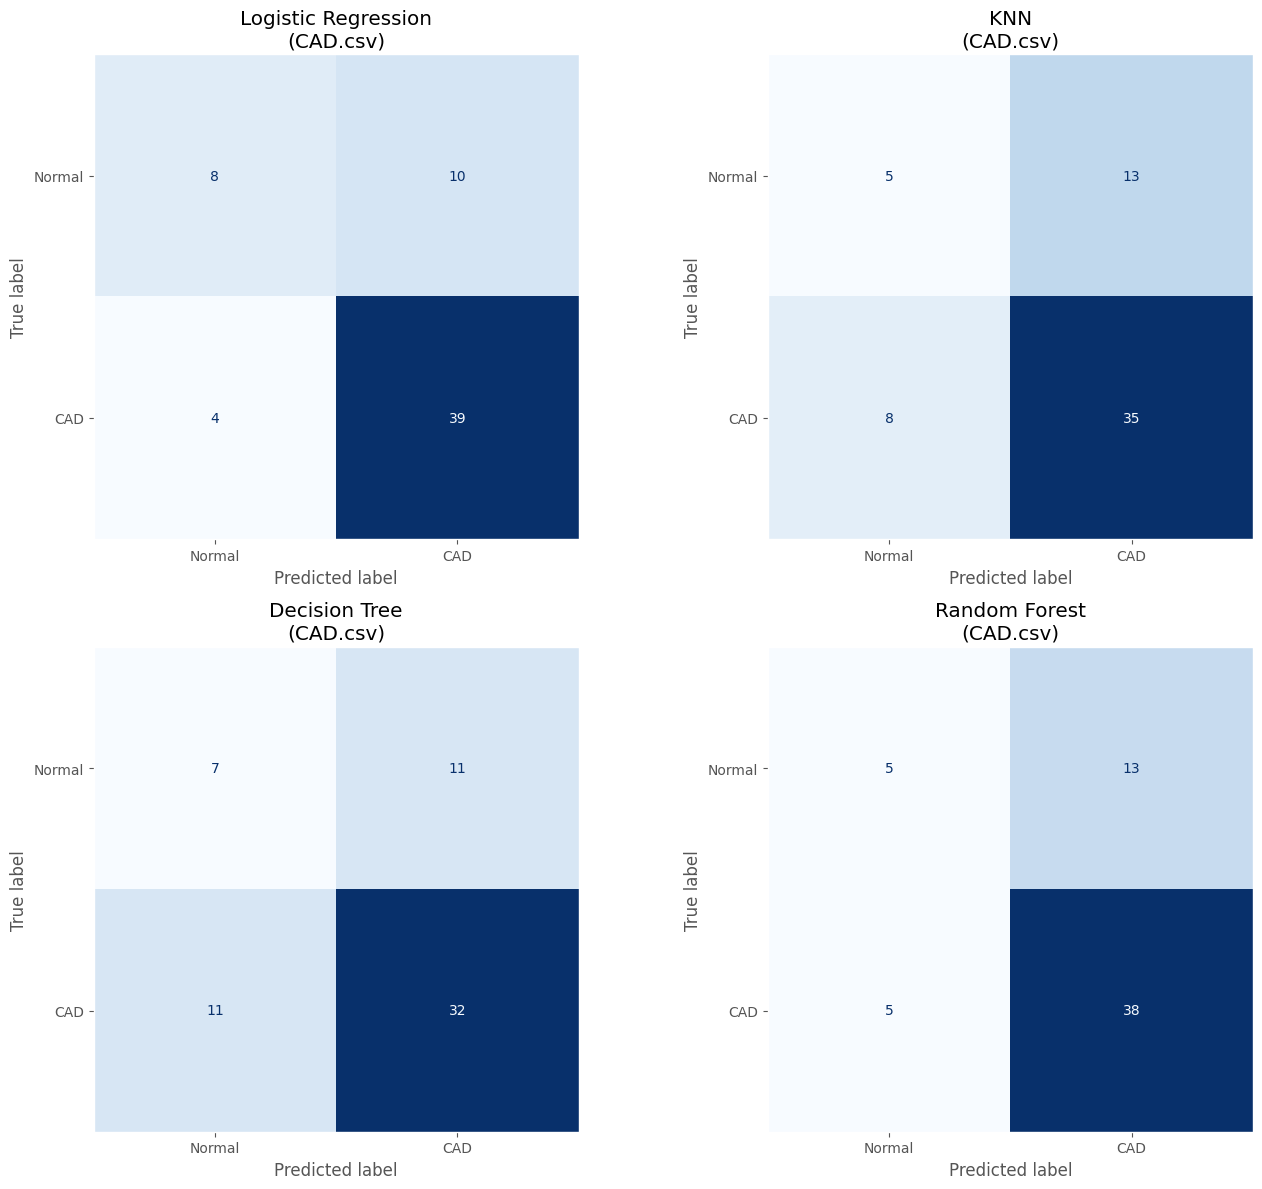


Generating ROC Curves for CAD.csv...


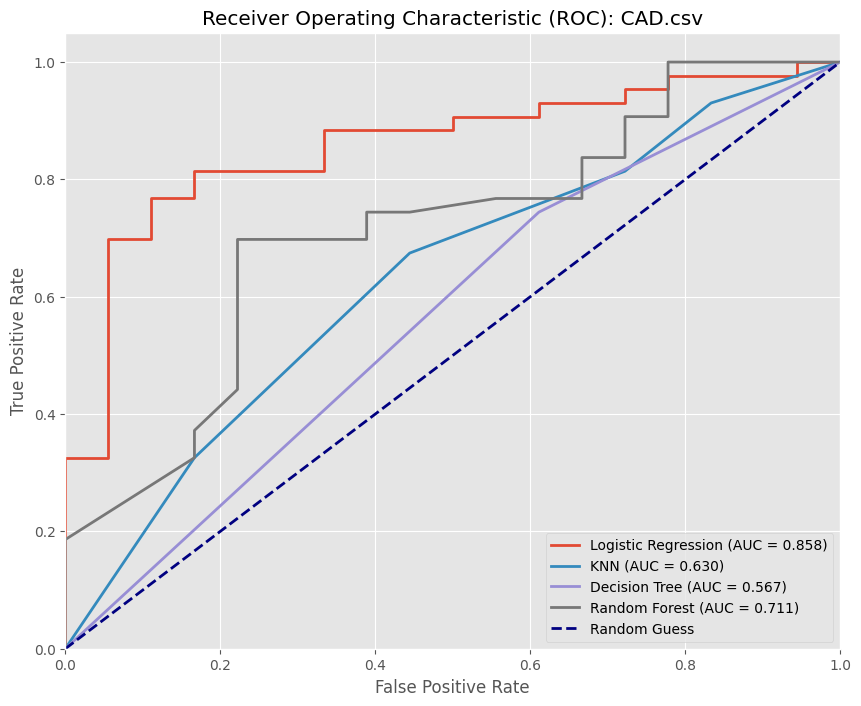


Generating Individual Metric Plots for CAD.csv...


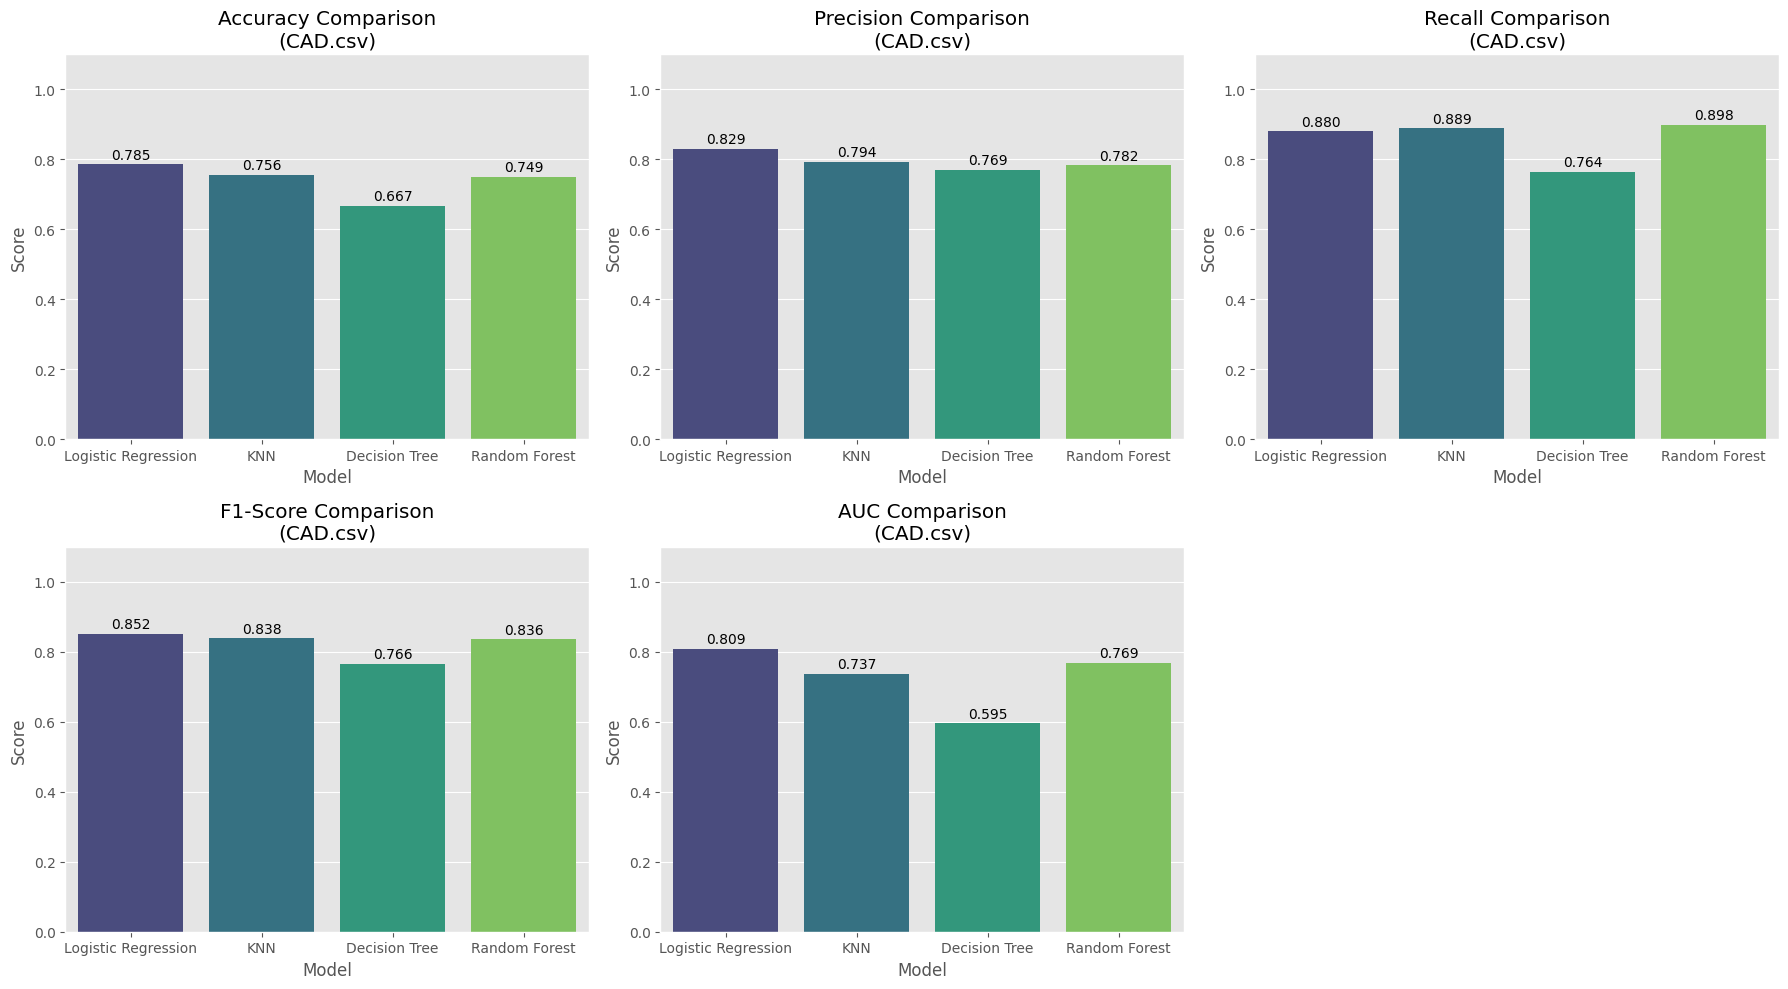


Model Comparison Table (D1 - CAD.csv):
              Model  Accuracy  Precision   Recall  F1-Score      AUC
Logistic Regression  0.785410   0.829468 0.879704  0.851797 0.809179
      Random Forest  0.749016   0.782305 0.897886  0.835601 0.769012
                KNN  0.755683   0.793651 0.888795  0.838207 0.736865
      Decision Tree  0.666995   0.769127 0.764059  0.766108 0.595428

==================== Testing Models on DataClean-fullage.csv (D2) ====================
Finished Logistic Regression on DataClean-fullage.csv (D2): AUC = 0.6165
Finished KNN on DataClean-fullage.csv (D2): AUC = 0.6329
Finished Decision Tree on DataClean-fullage.csv (D2): AUC = 0.6207
Finished Random Forest on DataClean-fullage.csv (D2): AUC = 0.7605

Generating Confusion Matrices for DataClean-fullage.csv...


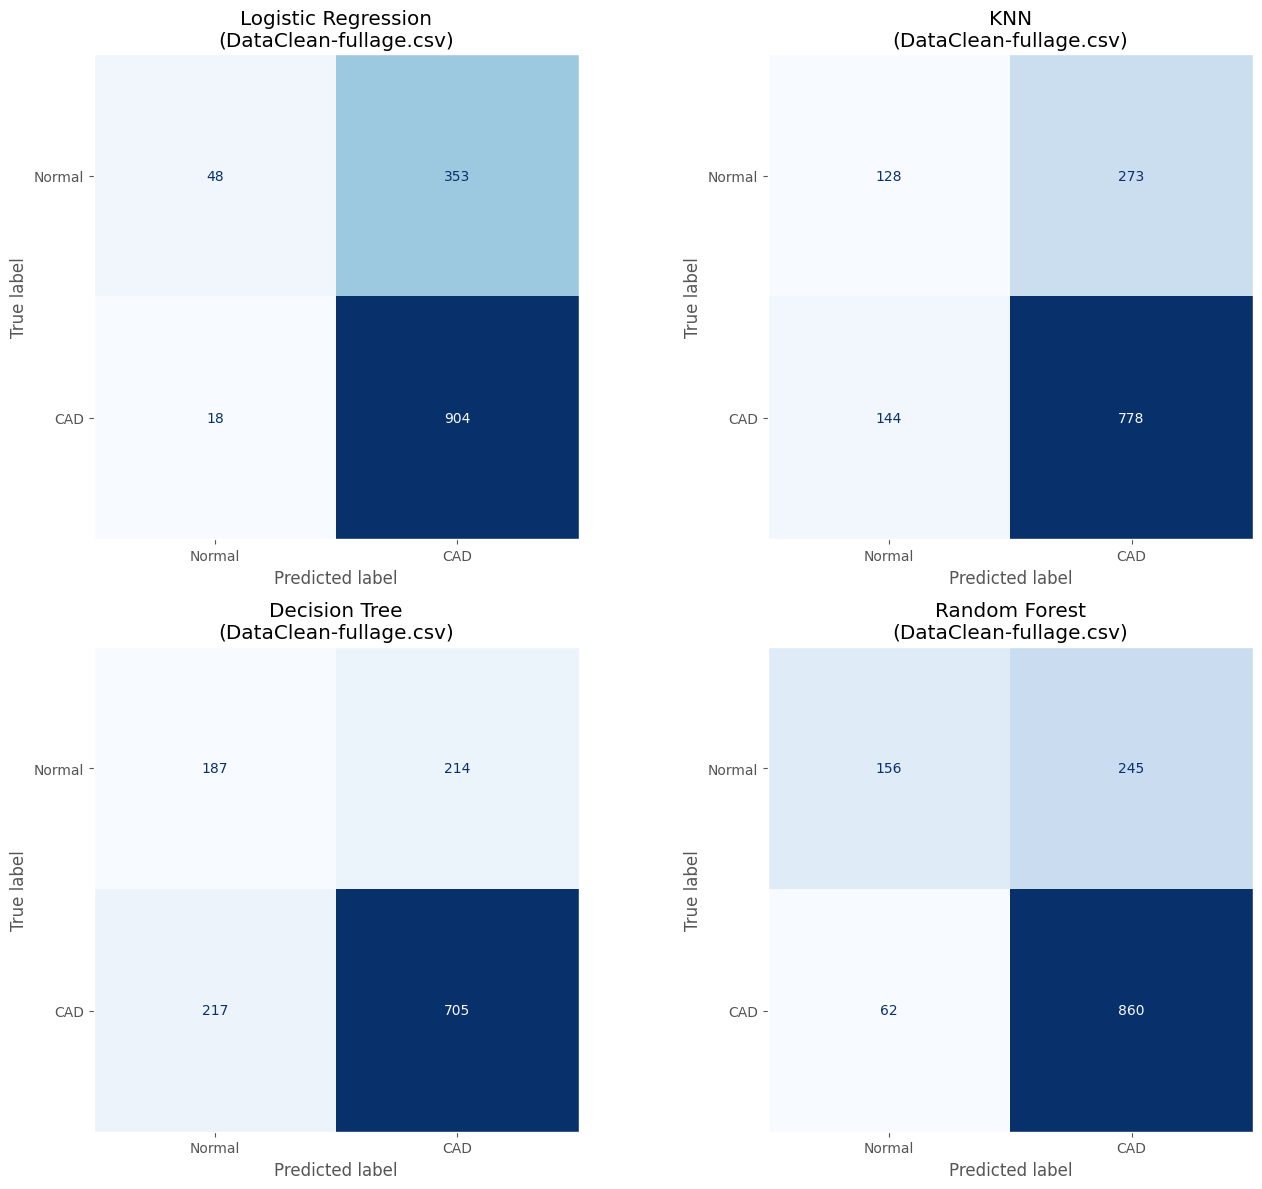


Generating ROC Curves for DataClean-fullage.csv...


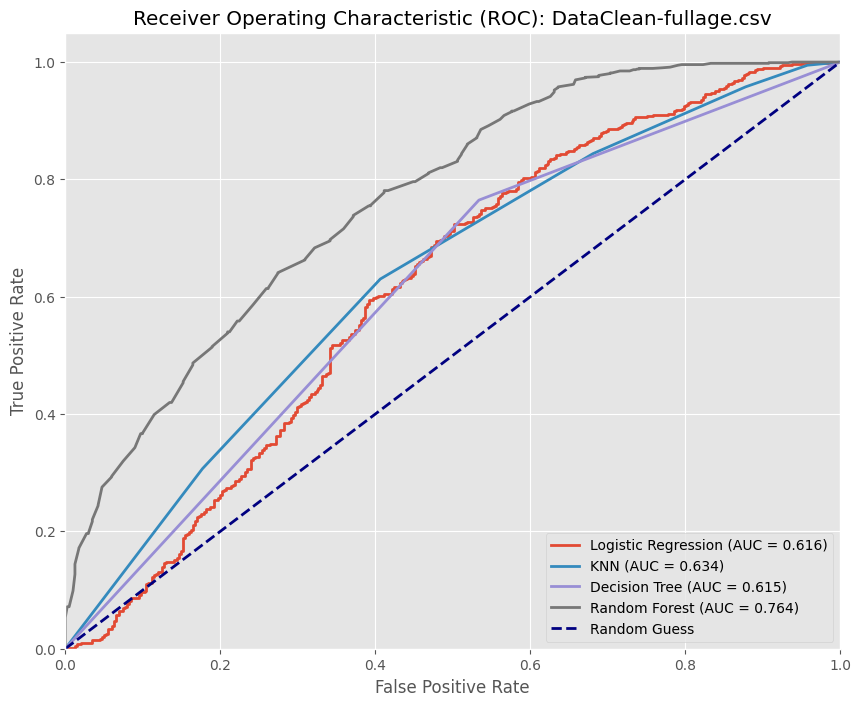


Generating Individual Metric Plots for DataClean-fullage.csv...


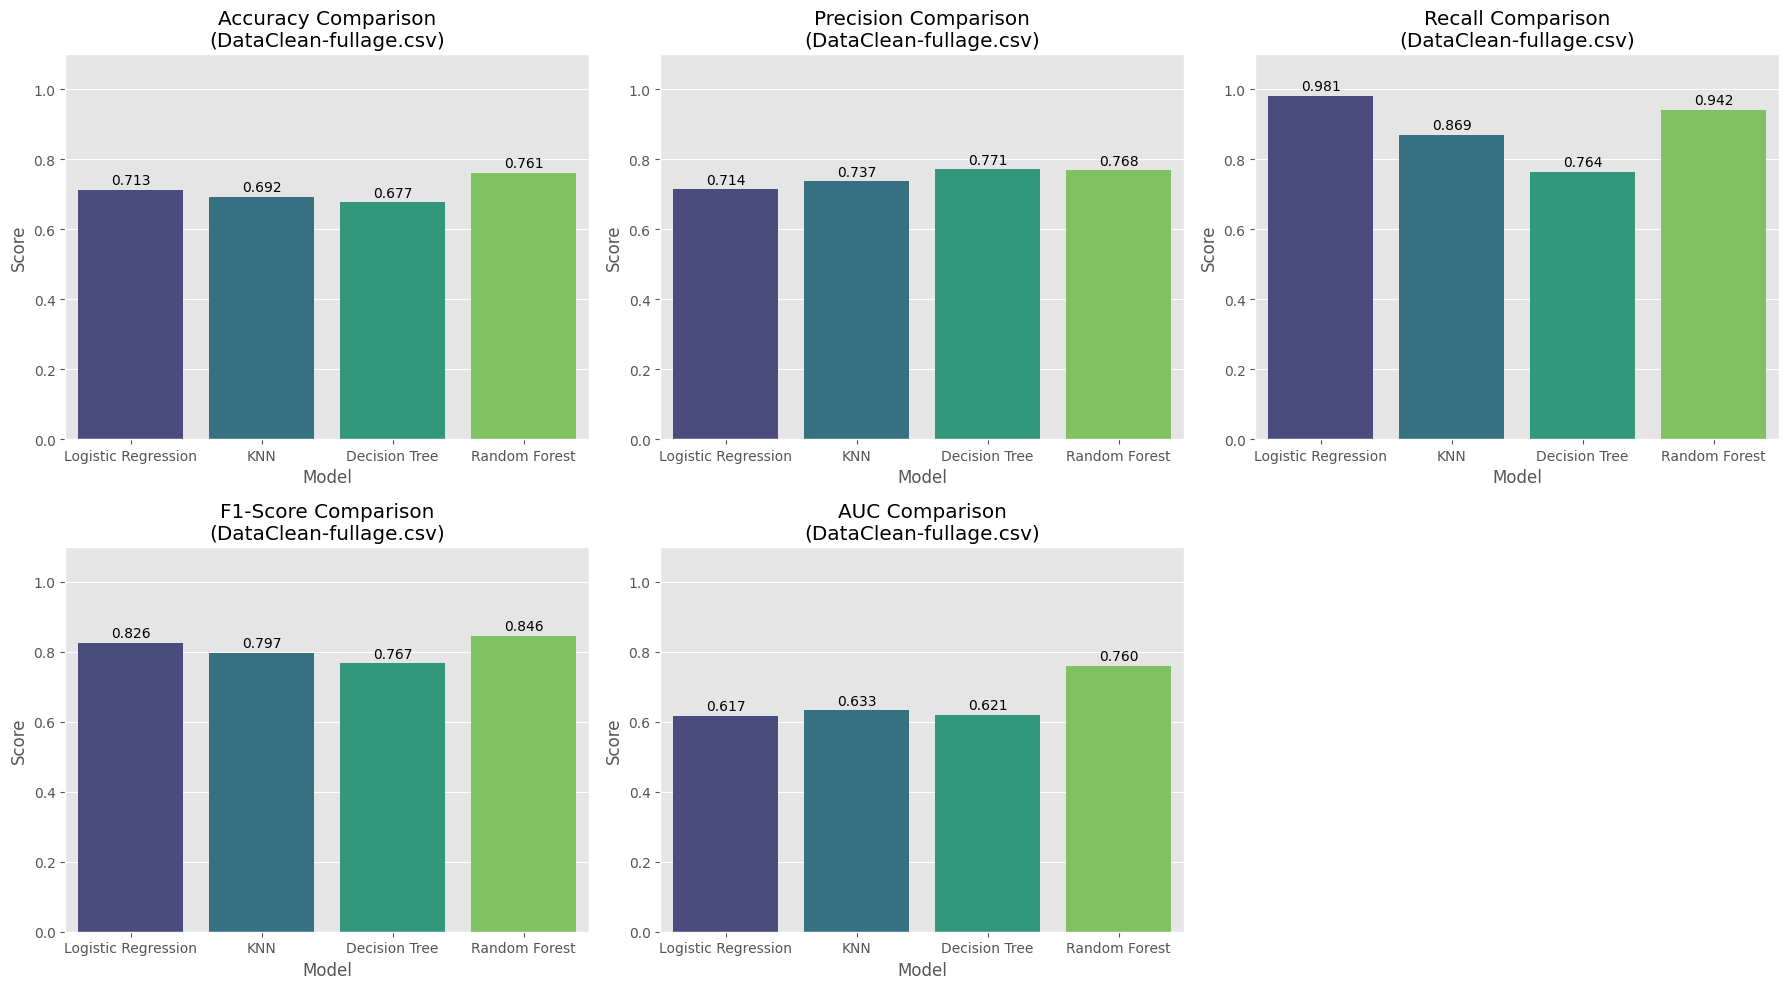


Model Comparison Table (D2 - DataClean-fullage.csv):
              Model  Accuracy  Precision   Recall  F1-Score      AUC
      Random Forest  0.761456   0.768331 0.941854  0.846267 0.760457
                KNN  0.692179   0.736695 0.869169  0.797456 0.632894
      Decision Tree  0.677051   0.771315 0.763509  0.767202 0.620721
Logistic Regression  0.712903   0.714194 0.980690  0.826477 0.616517


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 6.1 Importing Additional Libraries
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# 6.2 Adjusting Settings
RANDOM_STATE = 42
plt.style.use('ggplot')

def load_and_preprocess():
    """Helper to load and harmonize datasets based on previous steps."""
    try:
        df_cad = pd.read_csv('CAD.csv')
        df_fullage = pd.read_csv('DataClean-fullage.csv')
    except FileNotFoundError:
        print("CSV files not found. Please ensure CAD.csv and DataClean-fullage.csv are in the directory.")
        return None, None

    # Harmonize Targets
    df_cad['Target'] = df_cad['Cath'].apply(lambda x: 1 if x in ['Cad', 'cad'] else 0)
    df_fullage['Target'] = df_fullage['cad']

    # Harmonize Categorical (Simplified)
    for df in [df_cad, df_fullage]:
        for col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].map({'Y': 1, 'N': 0, 'y': 1, 'n': 0, 'Male': 1, 'Fmale': 0, 'M': 1, 'F': 0}).fillna(df[col])

    return df_cad, df_fullage

# 6.3 Defining models that will be used and compared
def get_ml_results(X, y, title="Dataset"):
    """Runs the requested ML models and returns evaluation metrics."""
    print(f"\n{'='*20} Testing Models on {title} {'='*20}")

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    }

    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    results_summary = []

    for name, model in models.items():
        # Create pipeline for scaling
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', model)
        ])

        # Cross-validation
        cv_results = cross_validate(pipeline, X, y, cv=cv, scoring=scoring)

        summary = {
            'Model': name,
            'Accuracy': cv_results['test_accuracy'].mean(),
            'Precision': cv_results['test_precision'].mean(),
            'Recall': cv_results['test_recall'].mean(),
            'F1-Score': cv_results['test_f1'].mean(),
            'AUC': cv_results['test_roc_auc'].mean()
        }
        results_summary.append(summary)
        print(f"Finished {name} on {title}: AUC = {summary['AUC']:.4f}")

    return pd.DataFrame(results_summary)

def plot_confusion_matrices(X, y, title="Dataset"):
    """Plots confusion matrices for the 4 models using a train-test split."""
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    }

    # Split data for evaluation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.ravel()

    print(f"\nGenerating Confusion Matrices for {title}...")

    for i, (name, model) in enumerate(models.items()):
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', model)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'CAD'])

        disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
        axes[i].set_title(f'{name}\n({title})')
        axes[i].grid(False) # Clear grid for better visibility

    plt.tight_layout()
    plt.show()

def plot_roc_curves(X, y, title="Dataset"):
    """Plots ROC curves for the 4 models on a single graph."""
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    }

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

    plt.figure(figsize=(10, 8))

    print(f"\nGenerating ROC Curves for {title}...")

    for name, model in models.items():
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', model)
        ])

        pipeline.fit(X_train, y_train)

        # All selected models have predict_proba
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC): {title}')
    plt.legend(loc="lower right")
    plt.show()

def plot_detailed_metrics(results_df, title):
    """Plots each performance metric in an individual subplot for comparison."""
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
    # Create a grid for the metrics
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    print(f"\nGenerating Individual Metric Plots for {title}...")

    for i, metric in enumerate(metrics):
        # Added hue='Model' and legend=False to suppress FutureWarnings
        sns.barplot(x='Model', y=metric, data=results_df, ax=axes[i], palette='viridis', hue='Model', legend=False)
        axes[i].set_title(f'{metric} Comparison\n({title})')
        axes[i].set_ylim(0, 1.1)
        axes[i].set_ylabel('Score')

        # Add value labels on top of bars
        for p in axes[i].patches:
            axes[i].annotate(format(p.get_height(), '.3f'),
                             (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='center', xytext=(0, 7),
                             textcoords='offset points')

    # Remove the extra subplot in the 2x3 grid
    if len(metrics) < len(axes):
        fig.delaxes(axes[-1])

    plt.tight_layout()
    plt.show()

# 6.4 Dataset-Specific Analysis Functions
def analyze_dataset_1(df_cad):
    """Performs full ML analysis for the primary CAD.csv dataset."""
    if df_cad is None or df_cad.empty:
        print("Dataset 1 is empty or not loaded.")
        return None

    features_d1 = ['Age', 'Sex', 'BMI', 'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH',
                    'FBS', 'CR', 'TG', 'LDL', 'HDL', 'HB', 'WBC', 'EF-TTE']

    X_d1 = df_cad[features_d1].apply(pd.to_numeric, errors='coerce').fillna(df_cad[features_d1].median())
    y_d1 = df_cad['Target']

    results = get_ml_results(X_d1, y_d1, "CAD.csv (D1)")
    plot_confusion_matrices(X_d1, y_d1, "CAD.csv")
    plot_roc_curves(X_d1, y_d1, "CAD.csv")
    plot_detailed_metrics(results, "CAD.csv")

    print("\nModel Comparison Table (D1 - CAD.csv):")
    print(results.sort_values(by='AUC', ascending=False).to_string(index=False))
    return results

def analyze_dataset_2(df_fullage):
    """Performs full ML analysis for the secondary DataClean-fullage.csv dataset."""
    if df_fullage is None or df_fullage.empty:
        print("Dataset 2 is empty or not loaded.")
        return None

    features_d2 = ['age', 'gender', 'alcohol', 'glucose', 'creatinine', 'eject_fraction',
                   'leuk_count', 'platelets', 'bnp', 'haemoglobin', 'raised_cardiac', 'urea']

    X_d2 = df_fullage[features_d2].apply(pd.to_numeric, errors='coerce').fillna(df_fullage[features_d2].median())
    y_d2 = df_fullage['Target']

    results = get_ml_results(X_d2, y_d2, "DataClean-fullage.csv (D2)")
    plot_confusion_matrices(X_d2, y_d2, "DataClean-fullage.csv")
    plot_roc_curves(X_d2, y_d2, "DataClean-fullage.csv")
    plot_detailed_metrics(results, "DataClean-fullage.csv")

    print("\nModel Comparison Table (D2 - DataClean-fullage.csv):")
    print(results.sort_values(by='AUC', ascending=False).to_string(index=False))
    return results

# 6.5 Execution Entry Point
def main():
    df_cad, df_fullage = load_and_preprocess()
    if df_cad is not None:
        analyze_dataset_1(df_cad)
    if df_fullage is not None:
        analyze_dataset_2(df_fullage)

if __name__ == "__main__":
    main()


==================== Testing Models on CAD.csv (D1) ====================
Finished Logistic Regression on CAD.csv (D1): AUC = 0.8092
Finished KNN on CAD.csv (D1): AUC = 0.7369
Finished Decision Tree on CAD.csv (D1): AUC = 0.5954
Finished Random Forest on CAD.csv (D1): AUC = 0.7690

==================== Testing Models on DataClean-fullage.csv (D2) ====================
Finished Logistic Regression on DataClean-fullage.csv (D2): AUC = 0.6165
Finished KNN on DataClean-fullage.csv (D2): AUC = 0.6329
Finished Decision Tree on DataClean-fullage.csv (D2): AUC = 0.6207
Finished Random Forest on DataClean-fullage.csv (D2): AUC = 0.7605

Model Comparison Table (D1 - CAD.csv):
              Model  Accuracy  Precision   Recall  F1-Score      AUC
Logistic Regression  0.785410   0.829468 0.879704  0.851797 0.809179
      Random Forest  0.749016   0.782305 0.897886  0.835601 0.769012
                KNN  0.755683   0.793651 0.888795  0.838207 0.736865
      Decision Tree  0.666995   0.769127 0.764059 

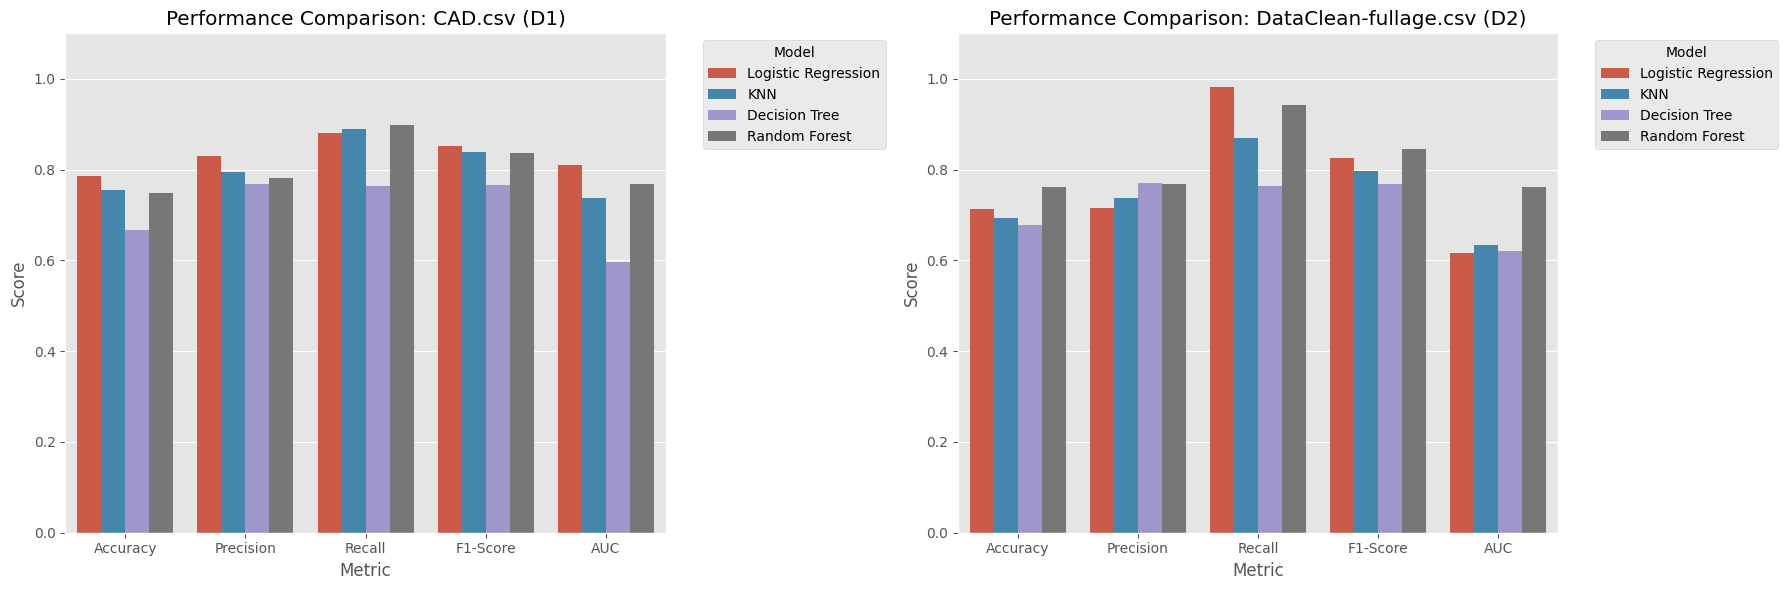


==================== Cross-Dataset Generalization Test ====================
Generalization Performance (D1 Trained -> D2 Tested): AUC = 0.7018


In [4]:
#This part was my first submission
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 6.1 Importing Additional Libraries
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

# 6.2 Adjusting Settings
RANDOM_STATE = 42
plt.style.use('ggplot')

def load_and_preprocess():
    """Helper to load and harmonize datasets based on previous steps."""
    try:
        df_cad = pd.read_csv('CAD.csv')
        df_fullage = pd.read_csv('DataClean-fullage.csv')
    except FileNotFoundError:
        print("CSV files not found. Please ensure CAD.csv and DataClean-fullage.csv are in the directory.")
        return None, None

    # Harmonize Targets
    df_cad['Target'] = df_cad['Cath'].apply(lambda x: 1 if x in ['Cad', 'cad'] else 0)
    df_fullage['Target'] = df_fullage['cad']

    # Harmonize Categorical (Simplified)
    for df in [df_cad, df_fullage]:
        for col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].map({'Y': 1, 'N': 0, 'y': 1, 'n': 0, 'Male': 1, 'Fmale': 0, 'M': 1, 'F': 0}).fillna(df[col])

    return df_cad, df_fullage

# 6.3 Defining models that will be used and compared
def get_ml_results(X, y, title="Dataset"):
    """Runs the requested ML models and returns evaluation metrics."""
    print(f"\n{'='*20} Testing Models on {title} {'='*20}")

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    }

    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    results_summary = []

    for name, model in models.items():
        # Create pipeline for scaling
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', model)
        ])

        # Cross-validation
        cv_results = cross_validate(pipeline, X, y, cv=cv, scoring=scoring)

        summary = {
            'Model': name,
            'Accuracy': cv_results['test_accuracy'].mean(),
            'Precision': cv_results['test_precision'].mean(),
            'Recall': cv_results['test_recall'].mean(),
            'F1-Score': cv_results['test_f1'].mean(),
            'AUC': cv_results['test_roc_auc'].mean()
        }
        results_summary.append(summary)
        print(f"Finished {name} on {title}: AUC = {summary['AUC']:.4f}")

    return pd.DataFrame(results_summary)

# 6.4 Machine Learning and comparing
def main():
    df_cad, df_fullage = load_and_preprocess()
    if df_cad is None: return

    # --- 1. Train and Evaluate on Dataset 1 (D1 - CAD.csv) ---
    features_d1 = ['Age', 'Sex', 'BMI', 'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH',
                    'FBS', 'CR', 'TG', 'LDL', 'HDL', 'HB', 'WBC', 'EF-TTE']

    X_d1 = df_cad[features_d1].apply(pd.to_numeric, errors='coerce').fillna(df_cad[features_d1].median())
    y_d1 = df_cad['Target']

    d1_results = get_ml_results(X_d1, y_d1, "CAD.csv (D1)")

    # --- 2. Train and Evaluate on Dataset 2 (D2 - DataClean-fullage.csv) ---
    # Features specific to the second dataset as defined in your project document
    features_d2 = ['age', 'gender', 'alcohol', 'glucose', 'creatinine', 'eject_fraction',
                   'leuk_count', 'platelets', 'bnp', 'haemoglobin', 'raised_cardiac', 'urea']

    X_d2 = df_fullage[features_d2].apply(pd.to_numeric, errors='coerce').fillna(df_fullage[features_d2].median())
    y_d2 = df_fullage['Target']

    d2_results = get_ml_results(X_d2, y_d2, "DataClean-fullage.csv (D2)")

    # --- 3. Results Tables ---
    print("\nModel Comparison Table (D1 - CAD.csv):")
    print(d1_results.sort_values(by='AUC', ascending=False).to_string(index=False))

    print("\nModel Comparison Table (D2 - DataClean-fullage.csv):")
    print(d2_results.sort_values(by='AUC', ascending=False).to_string(index=False))

    # --- 4. Visualizations ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot for Dataset 1
    melted_d1 = d1_results.melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=melted_d1, x='Metric', y='Score', hue='Model', ax=ax1)
    ax1.set_title('Performance Comparison: CAD.csv (D1)')
    ax1.set_ylim(0, 1.1)
    ax1.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Plot for Dataset 2
    melted_d2 = d2_results.melt(id_vars='Model', var_name='Metric', value_name='Score')
    sns.barplot(data=melted_d2, x='Metric', y='Score', hue='Model', ax=ax2)
    ax2.set_title('Performance Comparison: DataClean-fullage.csv (D2)')
    ax2.set_ylim(0, 1.1)
    ax2.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # --- 5. Generalization Test (Train on D1, Test on D2) ---
    print("\n" + "="*20 + " Cross-Dataset Generalization Test " + "="*20)
    common_d1 = ['Age', 'Sex', 'DM', 'HTN', 'Current Smoker']
    common_d2 = ['age', 'gender', 'diabetes', 'hypertension', 'smoking']

    X_train = df_cad[common_d1].apply(pd.to_numeric, errors='coerce').fillna(df_cad[common_d1].median())
    y_train = df_cad['Target']
    X_test = df_fullage[common_d2].apply(pd.to_numeric, errors='coerce').fillna(df_fullage[common_d2].median())
    y_test = df_fullage['Target']

    X_train.columns = ['age', 'sex', 'diabetes', 'hypertension', 'smoking']
    X_test.columns = ['age', 'sex', 'diabetes', 'hypertension', 'smoking']

    gen_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
    ])

    gen_pipeline.fit(X_train, y_train)
    y_proba = gen_pipeline.predict_proba(X_test)[:, 1]
    gen_auc = roc_auc_score(y_test, y_proba)
    print(f"Generalization Performance (D1 Trained -> D2 Tested): AUC = {gen_auc:.4f}")

if __name__ == "__main__":
    main()